<a href="https://colab.research.google.com/gist/will-hill/d8144f19eecd1ad378296cfa7972adb1/polars_cudf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intro to Polars and Polars with NVIDIA cuDF GPU Acceleration

## Key Takeaways

- Polars with NVIDIA cuDF --> NVIDIA GPU acceleration for Polars Lazy Evaluation (not eager)
- Polars with NVIDIA cuDF --> Polars code unchanged except collect() `engine` parameter
- Streaming engines process larger-than-memory data on CPU and GPU
- The GPU doesn't win everything
- Silent CPU fallback --> `raise_on_fail=True` to error, `POLARS_VERBOSE=1` to warn

### Verify GPU and CUDA

In [1]:
!nvidia-smi

Thu Jul 30 18:47:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    On  |   00000000:E1:00.0 Off |                  Off |
| 30%   33C    P8             11W /  600W |       2MiB /  97887MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Host Specs as Tested

In [2]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:           251Gi        12Gi       215Gi        14Mi        25Gi       238Gi
Swap:          8.0Gi       420Mi       7.6Gi


In [3]:
!lscpu | grep "Model name"

Model name:                              AMD Ryzen Threadripper PRO 7965WX 24-Cores


In [4]:
!nproc

48


<br/>

### Install Dependencies

In [5]:
# Local machine (CUDA 13):
# !uv add cudf-polars-cu13

# Google Colab (CUDA 12):
# !uv add cudf-polars-cu12

### Imports and Versions

In [6]:
import polars as pl
import polars.selectors as cs
import cudf_polars

pl.__version__, cudf_polars.__version__

('1.39.3', '26.06.00')

<br/>

---

# Sample Stock Market Data

In [7]:
![ -f usa_stocks_30m.parquet ] || wget "https://drive.usercontent.google.com/download?id=1yFLiopGxE5sc-YhjWaTfr2__ZidSFY39&export=download&confirm=t" -O usa_stocks_30m.parquet

--2026-07-30 18:47:52--  https://drive.usercontent.google.com/download?id=1yFLiopGxE5sc-YhjWaTfr2__ZidSFY39&export=download&confirm=t
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 192.178.218.132, 2607:f8b0:4004:c08::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|192.178.218.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 588355642 (561M) [application/octet-stream]
Saving to: ‘usa_stocks_30m.parquet’

usa_stocks_30m.parq 100%[===================>] 561.10M   112MB/s    in 5.2s    

2026-07-30 18:47:58 (108 MB/s) - ‘usa_stocks_30m.parquet’ saved [588355642/588355642]



In [8]:
stocks_lazy = pl.scan_parquet("usa_stocks_30m.parquet")

In [9]:
stocks_lazy

<br/>

# Inspect Column Types
### Polars include data types when displayed in Jupyter

In [10]:
(stocks_lazy
 .head(3)
 .collect(engine='streaming'))

datetime,open,high,low,close,volume,ticker
datetime[ms],f64,f64,f64,f64,i64,str
1999-11-18 17:00:00,45.56,50.0,45.5,46.0,9275000,"""A"""
1999-11-18 17:30:00,46.0,47.69,45.82,46.57,3200900,"""A"""
1999-11-18 18:00:00,46.56,46.63,41.0,41.0,3830500,"""A"""


### Can also check data types directly

In [11]:
(stocks_lazy
 .head(3)
 .collect(engine='streaming')
 .dtypes)

[Datetime(time_unit='ms', time_zone=None),
 Float64,
 Float64,
 Float64,
 Float64,
 Int64,
 String]

<br/>

---

# Lazy v Eager
Polars has two modes of execution:
 - `Eager` - Execute each operation sequentially as written, and immediately
 - `Lazy` - Optimize all operations in a query plan before execution (more below)
   

**Note** 
 - `read_parquet()` will load the entire data frame into memory for eager execution
 - `scan_parquet()` will load a lazily executed data frame

In [12]:
print(type(pl.read_parquet("usa_stocks_30m.parquet")))

print(type(pl.scan_parquet("usa_stocks_30m.parquet")))

<class 'polars.dataframe.frame.DataFrame'>
<class 'polars.lazyframe.frame.LazyFrame'>


**Note** The code below is written to highlight the eager vs lazy execution.

### Eager Execution

In [13]:
%%time

(
    pl.read_parquet("usa_stocks_30m.parquet")
    
    # .with_columns(
    #     ret    = pl.col("close").pct_change().over("ticker"),
    #     sma50  = pl.col("close").rolling_mean(10).over("ticker"),
    #     rng    = (pl.col("high") - pl.col("low")) / pl.col("open"),
    # )
    # replacing single with_columns() above code with 3 with_columns() to demonstrate optimization capabilities
    .with_columns(ret=pl.col("close").pct_change().over("ticker"))
    .with_columns(sma50=pl.col("close").rolling_mean(50).over("ticker"))
    .with_columns(rng=(pl.col("high") - pl.col("low")) / pl.col("open"))
    
    .filter(pl.col("ticker") == "NVDA")                 # pushable (partition key)
    .filter(pl.col("datetime").dt.year() >= 2010)       # NOT pushable past windows
    
    .group_by(pl.col("datetime").dt.date().alias("date"))
    .agg(
        vol   = pl.col("ret").std(),
        srng  = pl.col("rng").mean(),
        dvol  = pl.col("volume").sum(),
    )
    .select("date", "vol", "srng", "dvol")
    .head(3)
)

CPU times: user 16.5 s, sys: 2.61 s, total: 19.1 s
Wall time: 1.87 s


date,vol,srng,dvol
date,f64,f64,i64
2020-08-12,0.007735,0.007549,8575222
2018-06-15,0.00243,0.004354,7115922
2011-04-13,0.005979,0.00895,18213460


### Lazy (Optimized) Execution
**Note** Order is not guaranteed in Polars. The eager and lazy results might not match. 

In [14]:
%%time

# same as above execpt scan_parquet() instead of read_parquet()

stock_query = (
    # scan_parquet, not read_parquet
    pl.scan_parquet("usa_stocks_30m.parquet")
    
    # .with_columns(
    #     ret    = pl.col("close").pct_change().over("ticker"),
    #     sma50  = pl.col("close").rolling_mean(10).over("ticker"),
    #     rng    = (pl.col("high") - pl.col("low")) / pl.col("open"),
    # )
    # replacing single with_columns() above code with 3 with_columns() to demonstrate optimization capabilities
    .with_columns(ret=pl.col("close").pct_change().over("ticker"))
    .with_columns(sma50=pl.col("close").rolling_mean(50).over("ticker"))
    .with_columns(rng=(pl.col("high") - pl.col("low")) / pl.col("open"))
    
    .filter(pl.col("ticker") == "NVDA")                 # pushable (partition key)
    .filter(pl.col("datetime").dt.year() >= 2010)       # NOT pushable past windows
    
    .group_by(pl.col("datetime").dt.date().alias("date"))
    
    .agg(
        vol   = pl.col("ret").std(),
        srng  = pl.col("rng").mean(),
        dvol  = pl.col("volume").sum(),
    )
    .select("date", "vol", "srng", "dvol")
    .head(3)
)
stock_query.collect(engine="streaming")

CPU times: user 107 ms, sys: 14.4 ms, total: 121 ms
Wall time: 14.5 ms


date,vol,srng,dvol
date,f64,f64,i64
2018-10-12,0.013927,0.011565,10662214
2024-02-09,0.00435,0.004863,30589721
2019-03-14,0.003913,0.007374,10139699


<br/>

# Optimization Visualization

The query visualization below requires graphviz.  
Query visualization is not required to run Polars.  
```bash
sudo apt install graphviz  
uv add graphviz
```

In [15]:
import graphviz
from IPython.display import SVG

### Unoptimized Query Plan

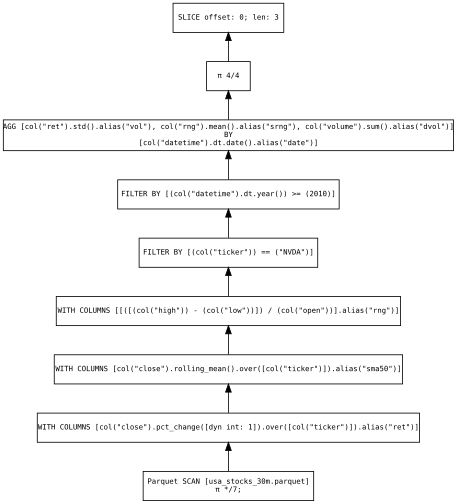

In [16]:
# Note --> optimized=False
dot = stock_query.show_graph(optimized=False, raw_output=True)
dot = dot.replace("{", '{\ngraph [size="10,7"]\nnode [fontsize=9]\n', 1)
SVG(graphviz.Source(dot).pipe(format="svg"))

### Optimized Query Plan
Same query as above: `stock_query`  
  
Note the changes in the query plan.   

 - **Predicate Pushdown** - `FILTER BY ticker == "NVDA"` predicate pushed to parquet scan, reducing IO
 - **Dead Code** - `WITH COLUMNS ... sma50` node removed since it is useless
 - **Projection Update**  - parquet scan reads π 7/7 instead of π */7
 - **Filter Efficiency** - datetime year filter now runs before the rng computation, reducing rows computed
 - **Projection Removed** - eliminated the `π 4/4` node above the `AGG...` since all 4 columns kept, no need

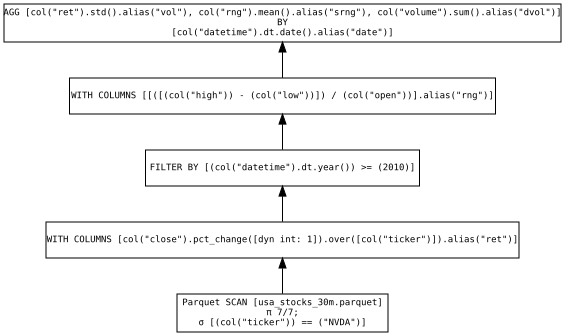

In [17]:
# Note --> optimized=True
dot = stock_query.show_graph(optimized=True, engine='streaming', raw_output=True)
dot = dot.replace("{", '{\ngraph [size="10,7"]\nnode [fontsize=9]\n', 1)
SVG(graphviz.Source(dot).pipe(format="svg"))

In [18]:
print(stock_query.explain())

AGGREGATE[maintain_order: false]
  [col("ret").std().alias("vol"), col("rng").mean().alias("srng"), col("volume").sum().alias("dvol")] BY [col("datetime").dt.date().alias("date")]
  FROM
   WITH_COLUMNS:
   [[([(col("high")) - (col("low"))]) / (col("open"))].alias("rng")] 
    FILTER [(col("datetime").dt.year()) >= (2010)]
    FROM
       WITH_COLUMNS:
       [col("close").pct_change([dyn int: 1]).over([col("ticker")]).alias("ret")] 
        Parquet SCAN [usa_stocks_30m.parquet]
        PROJECT 7/7 COLUMNS
        SELECTION: [(col("ticker")) == ("NVDA")]
        ESTIMATED ROWS: 36087094


<br/>

---

# Polars Engines

Different ways to `.collect()` a lazy query.  
This notebook focuses on streaming only.  
Each returns the same results with a different engine.   

| Engine | Call | Notes |
|---|---|---|
| **CPU streaming** | `.collect(engine="streaming")` | * Batched, out-of-core<br/> * Usually faster even if data fits in host memory<br/> * Enable globally: `pl.Config.set_engine_affinity("streaming")`.<br/> * Streaming engine since 1.31.1. |
| **CPU in-memory** | `.collect()` | * The default engine, `engine="auto"`.<br/> * Resolves via `Config.set_engine_affinity` / `POLARS_ENGINE_AFFINITY`, falling back to in-memory if unset |
| **GPU streaming** | `.collect(engine="gpu")`<br/>or<br/>`.collect(engine=pl.GPUEngine(executor="streaming"))` | * Works best with `scan_parquet` inputs<br/> * Default since 25.08<br/> * GPU acceleration with NVIDIA cuDF<br/> * Partitioned execution<br/> |
| **Multi-GPU Streaming** | `from cudf_polars.engine.ray import RayEngine`<br/>`with RayEngine() as engine:`<br/>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;`query.collect(engine=engine)` | * [cudf-polars Usage Docs](https://docs.rapids.ai/api/cudf/stable/cudf_polars/usage/) |

**Unsupported Fallbacks:** 
 - GPU query → CPU engine
 - GPU streaming → GPU in-memory
 - CPU streaming → CPU in-memory

## References
- [RAPIDS cudf-polars engine options — streaming default since 25.08](https://docs.rapids.ai/api/cudf/stable/cudf_polars/engine_options/)
- [RAPIDS streaming execution — partitioning, `engine="gpu"` equivalence](https://docs.rapids.ai/api/cudf/stable/cudf_polars/streaming_execution/)

<br/>

---

# 262 Million Transaction Rows
<b>transactions.parquet</b>
 - 262M rows of simulated retail transactions (2010-2020).   
 - 4.3 GB on disk
 - <b>~21 GB in memory</b>  

##### The following sample queries use transaction data

https://www.kaggle.com/datasets/conorsully1/simulated-transactions

In [19]:
![ -f transactions.parquet ] || wget "https://drive.usercontent.google.com/download?id=17X1jcGvsetdtYZR3m_Fkqlsy7nGeT-Ql&export=download&confirm=t" -O transactions.parquet

--2026-07-30 18:48:01--  https://drive.usercontent.google.com/download?id=17X1jcGvsetdtYZR3m_Fkqlsy7nGeT-Ql&export=download&confirm=t
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 192.178.218.132, 2607:f8b0:4004:c08::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|192.178.218.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4274457161 (4.0G) [application/octet-stream]
Saving to: ‘transactions.parquet’

transactions.parque 100%[===================>]   3.98G   101MB/s    in 41s     

2026-07-30 18:48:43 (99.2 MB/s) - ‘transactions.parquet’ saved [4274457161/4274457161]



### Data

In [20]:
tx_lazy = pl.scan_parquet('transactions.parquet')

tx_lazy.select(pl.len()).collect(engine="gpu").item(), tx_lazy.collect_schema()

(261969719,
 Schema([('CUST_ID', String),
         ('START_DATE', Date),
         ('END_DATE', Date),
         ('TRANS_ID', String),
         ('DATE', Date),
         ('YEAR', Int64),
         ('MONTH', Int64),
         ('DAY', Int64),
         ('EXP_TYPE', String),
         ('AMOUNT', Float64)]))

In [21]:
pl.scan_parquet('transactions.parquet').collect(engine="gpu")

CUST_ID,START_DATE,END_DATE,TRANS_ID,DATE,YEAR,MONTH,DAY,EXP_TYPE,AMOUNT
str,date,date,str,date,i64,i64,i64,str,f64
"""CI6XLYUMQK""",2015-05-01,null,"""T8I9ZB5A6X90UG8""",2015-09-11,2015,9,11,"""Motor/Travel""",20.27
"""CI6XLYUMQK""",2015-05-01,null,"""TZ4JSLS7SC7FO9H""",2017-02-08,2017,2,8,"""Motor/Travel""",12.85
"""CI6XLYUMQK""",2015-05-01,null,"""TTUKRDDJ6B6F42H""",2015-08-01,2015,8,1,"""Housing""",383.8
"""CI6XLYUMQK""",2015-05-01,null,"""TDUHFRUKGPPI6HD""",2019-03-16,2019,3,16,"""Entertainment""",5.72
"""CI6XLYUMQK""",2015-05-01,null,"""T0JBZHBMSVRFMMD""",2015-05-15,2015,5,15,"""Entertainment""",11.06
…,…,…,…,…,…,…,…,…,…
"""CIQJZREHDP""",2010-07-01,2017-03-01,"""TNIGHT68ESC48O5""",2013-05-24,2013,5,24,"""Groceries""",1.46
"""CIQJZREHDP""",2010-07-01,2017-03-01,"""TL84G1Z3BSW3Y7U""",2013-05-02,2013,5,2,"""Groceries""",1.37
"""CIQJZREHDP""",2010-07-01,2017-03-01,"""T1UU6CNJ3NZLRJ5""",2015-02-04,2015,2,4,"""Groceries""",1.73


---

# Sample Query 1 - Outlier Detection
##### Per-customer outlier detection: flag transactions more than 3σ above <i>that customer's</i> baseline
##### Window functions (<i>.over()</i>) + filter + group_by across all 262M rows

In [22]:
outliers_q = (
    tx_lazy
    .with_columns(z=(pl.col('AMOUNT') - pl.col('AMOUNT').mean().over('CUST_ID'))
                  / pl.col('AMOUNT').std().over('CUST_ID'))
    .filter(pl.col('z') > 3)
    # GPU --> Grouping + Agg + Calc
    .group_by('EXP_TYPE')
    .agg(pl.len().alias('n_outliers'), pl.col('z').max().alias('max_z'))
    .sort('n_outliers', descending=True)
)


### CPU Streaming

In [23]:
%%time

outliers_q.collect(engine='streaming')

CPU times: user 2min 10s, sys: 17.6 s, total: 2min 27s
Wall time: 11.4 s


EXP_TYPE,n_outliers,max_z
str,u32,f64
"""Housing""",1581386,10.549969
"""Motor/Travel""",1196697,22.212095
"""Bills and Utilities""",911344,6.633721
"""Education""",564596,9.878588
"""Health""",530149,13.200819
…,…,…
"""Entertainment""",176982,15.857898
"""Savings""",82914,8.449236
"""Groceries""",44914,7.86152


### GPU Streaming

In [24]:
%%time

outliers_q.collect(engine='gpu')

CPU times: user 3.37 s, sys: 1.41 s, total: 4.78 s
Wall time: 1.85 s


EXP_TYPE,n_outliers,max_z
str,u32,f64
"""Housing""",1581386,10.549969
"""Motor/Travel""",1196697,22.212095
"""Bills and Utilities""",911344,6.633721
"""Education""",564596,9.878588
"""Health""",530149,13.200819
…,…,…
"""Entertainment""",176982,15.857898
"""Savings""",82914,8.449236
"""Groceries""",44914,7.86152


---

# Sample Query 2 - Feature Extraction
##### Let's create a few new columns using the Polars .over() expression:

In [25]:
features_q = (
    tx_lazy.with_columns(
        # GPU --> over() w/ calc
        pct_of_cust=pl.col('AMOUNT') / pl.col('AMOUNT').sum().over('CUST_ID'),
        rank_in_cust=pl.col('AMOUNT').rank().over('CUST_ID'),
        share_of_type=pl.col('AMOUNT') / pl.col('AMOUNT').sum().over('EXP_TYPE'),
    )
    .select('CUST_ID', 'EXP_TYPE', 'pct_of_cust', 'rank_in_cust', 'share_of_type')
)

### CPU Streaming

In [26]:
%%time

features_q.collect(engine='streaming')

CPU times: user 3min 42s, sys: 17.7 s, total: 4min
Wall time: 21.7 s


CUST_ID,EXP_TYPE,pct_of_cust,rank_in_cust,share_of_type
str,str,f64,f64,f64
"""CI6XLYUMQK""","""Motor/Travel""",0.000137,3835.0,5.2246e-9
"""CI6XLYUMQK""","""Motor/Travel""",0.000087,2987.5,3.3121e-9
"""CI6XLYUMQK""","""Housing""",0.002598,5160.0,1.4272e-7
"""CI6XLYUMQK""","""Entertainment""",0.000039,309.5,1.6047e-9
"""CI6XLYUMQK""","""Entertainment""",0.000075,2538.0,3.1028e-9
…,…,…,…,…
"""CIQJZREHDP""","""Groceries""",0.000064,367.0,4.0055e-10
"""CIQJZREHDP""","""Groceries""",0.00006,320.0,3.7586e-10
"""CIQJZREHDP""","""Groceries""",0.000076,506.5,4.7462e-10


### GPU Streaming

In [27]:
%%time

features_q.collect(engine='gpu')

CPU times: user 8.74 s, sys: 2.12 s, total: 10.9 s
Wall time: 8.7 s


CUST_ID,EXP_TYPE,pct_of_cust,rank_in_cust,share_of_type
str,str,f64,f64,f64
"""CI6XLYUMQK""","""Motor/Travel""",0.000137,3835.0,5.2246e-9
"""CI6XLYUMQK""","""Motor/Travel""",0.000087,2987.5,3.3121e-9
"""CI6XLYUMQK""","""Housing""",0.002598,5160.0,1.4272e-7
"""CI6XLYUMQK""","""Entertainment""",0.000039,309.5,1.6047e-9
"""CI6XLYUMQK""","""Entertainment""",0.000075,2538.0,3.1028e-9
…,…,…,…,…
"""CIQJZREHDP""","""Groceries""",0.000064,367.0,4.0055e-10
"""CIQJZREHDP""","""Groceries""",0.00006,320.0,3.7586e-10
"""CIQJZREHDP""","""Groceries""",0.000076,506.5,4.7462e-10


---

# Sample Query 3 - Per-Group Distinct Counts
##### GPU Is **Not Always** Fastest
##### Exact per-group distinct counts (<i>n_unique</i>) run faster on the CPU streaming engine

In [28]:
active_q = (
     tx_lazy
     .group_by('EXP_TYPE', 'YEAR', 'MONTH')
     .agg(pl.col('CUST_ID').n_unique().alias('active_customers'),
          pl.col('AMOUNT').sum().alias('total_spend'))
     .sort('EXP_TYPE', 'YEAR', 'MONTH')
)

### CPU Streaming

In [29]:
%%time

active_q.collect(engine='streaming') # CPU streaming

CPU times: user 1min 6s, sys: 12.8 s, total: 1min 18s
Wall time: 1.78 s


EXP_TYPE,YEAR,MONTH,active_customers,total_spend
str,i64,i64,u32,f64
"""Bills and Utilities""",2010,1,577,252138.53
"""Bills and Utilities""",2010,2,1174,515369.19
"""Bills and Utilities""",2010,3,1778,791650.31
"""Bills and Utilities""",2010,4,2391,1.0886e6
"""Bills and Utilities""",2010,5,2968,1.3666e6
…,…,…,…,…
"""Tax""",2020,8,27833,1.1452e7
"""Tax""",2020,9,27317,1.1247e7
"""Tax""",2020,10,26810,1.1034e7


### GPU Streaming

In [30]:
%%time

active_q.collect(engine='gpu') # GPU Streaming

CPU times: user 6.04 s, sys: 1.16 s, total: 7.2 s
Wall time: 3.63 s


EXP_TYPE,YEAR,MONTH,active_customers,total_spend
str,i64,i64,u32,f64
"""Bills and Utilities""",2010,1,577,252138.53
"""Bills and Utilities""",2010,2,1174,515369.19
"""Bills and Utilities""",2010,3,1778,791650.31
"""Bills and Utilities""",2010,4,2391,1.0886e6
"""Bills and Utilities""",2010,5,2968,1.3666e6
…,…,…,…,…
"""Tax""",2020,8,27833,1.1452e7
"""Tax""",2020,9,27317,1.1247e7
"""Tax""",2020,10,26810,1.1034e7


<br/>

---

# CPU Fallback (silent or loud)
Not all Polars operations are GPU accelerated.   
To request GPU acceleration, add a feature request:  
- https://github.com/rapidsai/cudf

For example, dynamic group-by in not GPU accelerated as of cudf-polars version 26.06.  
Execution silently falls back to the CPU for the entire query.  
There are 3 ways to handle this:
1. `Silent` - the default is silent CPU fallback
2. `Warning`- set an env var <i>POLARS_VERBOSE=1</i> to get a <i>PerformanceWarning</i>.
3. `Error` - add <b><i>raise_on_fail=True</i></b> as an engine parameter to raise an error

### ⚠️ Raise Warning ⚠️

In [31]:
import os

# raise warning for CPU fallback
os.environ["POLARS_VERBOSE"] = "1" 

# to unset
# os.environ.pop("POLARS_VERBOSE", None)    

In [32]:
(
    stocks_lazy
    .set_sorted('datetime')
    .group_by_dynamic(index_column='datetime', every='1m', group_by='ticker')
    .agg(cs.numeric().mean())
    .collect(engine='gpu')
 )

/home/will/git/theta_options/.venv/lib/python3.12/site-packages/polars/lazyframe/frame.py:2464: PerformanceWarning: Query execution with GPU not possible: unsupported operations.
The errors were:
- NotImplementedError: Hint sorted unsupported
- NotImplementedError: group_by_dynamic
  return wrap_df(ldf.collect(engine, callback))


ticker,datetime,open,high,low,close,volume
str,datetime[ms],f64,f64,f64,f64,f64
"""A""",1999-11-18 17:00:00,45.56,50.0,45.5,46.0,9.275e6
"""A""",1999-11-18 17:30:00,46.0,47.69,45.82,46.57,3.2009e6
"""A""",1999-11-18 18:00:00,46.56,46.63,41.0,41.0,3.8305e6
"""A""",1999-11-18 18:30:00,41.0,43.38,40.37,42.38,3.6886e6
"""A""",1999-11-18 19:00:00,42.31,42.44,41.56,41.69,1.5843e6
…,…,…,…,…,…,…
"""GOOGL""",2024-03-13 21:00:00,140.66,140.69,140.29,140.31,840100.0
"""GOOGL""",2024-03-13 21:30:00,140.31,140.4,140.13,140.2,546898.0
"""GOOGL""",2024-03-13 22:00:00,140.2,140.27,139.52,139.68,844208.0


### ❌ Raise Error ❌
The following will raise and error since **group_by_dynamic()** in not GPU accelerated as of cudf-polars version 26.06

In [33]:
(
    stocks_lazy
    .set_sorted('datetime')
    .group_by_dynamic(index_column='datetime', every='1m', group_by='ticker')
    .agg(cs.numeric().mean())
    .collect(engine=pl.GPUEngine(raise_on_fail=True))   #  raise_on_fail=True, raise Error for CPU fallback
 )

ComputeError: 'cuda' conversion failed: NotImplementedError: ('Query execution with GPU not possible: unsupported operations.\nThe errors were:\n- NotImplementedError: Hint sorted unsupported\n- NotImplementedError: group_by_dynamic', [NotImplementedError('Hint sorted unsupported'), NotImplementedError('group_by_dynamic')])

<br/>